### Importación de datos



In [ ]:
%pip install pandas
%pip install matplotlib
%pip install folium

In [43]:

import pandas as pd # type: ignore

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [44]:
tienda['Total'] = tienda['Precio'] 
tienda2['Total'] = tienda2['Precio'] 
tienda3['Total'] = tienda3['Precio'] 
tienda4['Total'] = tienda4['Precio'] 
#suma_ingresos = tienda['Ingresos'].sum()
print(f"La suma de los ingresos de la tienda 1 es: {tienda['Total'].sum()}")
print(f"La suma de los ingresos de la tienda 2 es: {tienda2['Total'].sum()}")
print(f"La suma de los ingresos de la tienda 3 es: {tienda3['Total'].sum()}")
print(f"La suma de los ingresos de la tienda 4 es: {tienda4['Total'].sum()}")

suma_total = (
    tienda['Total'].sum() +
    tienda2['Total'].sum() +
    tienda3['Total'].sum() +
    tienda4['Total'].sum()
)

print(f"La suma total de ingresos de todas las tiendas es: {suma_total}")


La suma de los ingresos de la tienda 1 es: 1150880400.0
La suma de los ingresos de la tienda 2 es: 1116343500.0
La suma de los ingresos de la tienda 3 es: 1098019600.0
La suma de los ingresos de la tienda 4 es: 1038375700.0
La suma total de ingresos de todas las tiendas es: 4403619200.0


# 2. Ventas por categoría

In [65]:
# Agregar una columna 'Tienda' a cada DataFrame
tienda['Tienda'] = 'Tienda 1'
tienda2['Tienda'] = 'Tienda 2'
tienda3['Tienda'] = 'Tienda 3'
tienda4['Tienda'] = 'Tienda 4'

# Combinar todos los DataFrames en uno solo
df_combinado = pd.concat([tienda, tienda2, tienda3, tienda4], ignore_index=True)

# Contar la cantidad de productos vendidos por tienda y categoría
ventas_por_tienda_categoria = (
    df_combinado.groupby(['Tienda', 'Categoría del Producto'])
    .size()
    .reset_index(name='Cantidad Vendida')
)
#print('La cantidad de productos vendidos por tienda y categoría es:')
#print(ventas_por_tienda_categoria)

# Crear una tabla pivot para organizar los datos
tabla_pivot = ventas_por_tienda_categoria.pivot(
    index='Categoría del Producto',  # Filas: Categorías
    columns='Tienda',               # Columnas: Tiendas
    values='Cantidad Vendida'       # Valores: Cantidad vendida
).fillna(0)  # Rellenar valores faltantes con 0

print('Ventas por categoría y tienda:')
print(tabla_pivot)

# Encontrar la categoría más popular para cada tienda
categorias_populares = (
    ventas_por_tienda_categoria
    .loc[ventas_por_tienda_categoria.groupby('Tienda')['Cantidad Vendida'].idxmax()]
    .reset_index(drop=True)
)
print('\nLas categorías más populares por tienda son:')
print(categorias_populares)

Ventas por categoría y tienda:
Tienda                   Tienda 1  Tienda 2  Tienda 3  Tienda 4
Categoría del Producto                                         
Artículos para el hogar       171       181       177       201
Deportes y diversión          284       275       277       277
Electrodomésticos             312       305       278       254
Electrónicos                  448       422       451       451
Instrumentos musicales        182       224       177       170
Juguetes                      324       313       315       338
Libros                        173       197       185       187
Muebles                       465       442       499       480

Las categorías más populares por tienda son:
     Tienda Categoría del Producto  Cantidad Vendida
0  Tienda 1                Muebles               465
1  Tienda 2                Muebles               442
2  Tienda 3                Muebles               499
3  Tienda 4                Muebles               480


# 3. Calificación promedio de la tienda


In [46]:
# Combinar todos los DataFrames en uno solo
df_combinado = pd.concat([tienda, tienda2, tienda3, tienda4], ignore_index=True)

# Calcular el promedio de calificaciones por tienda
promedio_por_tienda = df_combinado.groupby('Tienda')['Calificación'].mean().reset_index(name='Calificación Promedio')

# Ordenar las tiendas por satisfacción del cliente
promedio_por_tienda_ordenado = promedio_por_tienda.sort_values(by='Calificación Promedio', ascending=False)

# Mostrar los resultados
print('El promedio de calificaciones por tienda es:')
print(promedio_por_tienda)

print('\nLas tiendas ordenadas por satisfacción del cliente son:')
print(promedio_por_tienda_ordenado)

El promedio de calificaciones por tienda es:
     Tienda  Calificación Promedio
0  Tienda 1               3.976685
1  Tienda 2               4.037304
2  Tienda 3               4.048326
3  Tienda 4               3.995759

Las tiendas ordenadas por satisfacción del cliente son:
     Tienda  Calificación Promedio
2  Tienda 3               4.048326
1  Tienda 2               4.037304
3  Tienda 4               3.995759
0  Tienda 1               3.976685


# 4. Productos más y menos vendidos

In [47]:
# Contar las ventas por producto para cada tienda
ventas_por_producto_tienda1 = tienda['Producto'].value_counts().reset_index()
ventas_por_producto_tienda1.columns = ['Producto', 'Total Ventas']

ventas_por_producto_tienda2 = tienda2['Producto'].value_counts().reset_index()
ventas_por_producto_tienda2.columns = ['Producto', 'Total Ventas']

ventas_por_producto_tienda3 = tienda3['Producto'].value_counts().reset_index()
ventas_por_producto_tienda3.columns = ['Producto', 'Total Ventas']

ventas_por_producto_tienda4 = tienda4['Producto'].value_counts().reset_index()
ventas_por_producto_tienda4.columns = ['Producto', 'Total Ventas']

# Mostrar los resultados
print('Ventas por producto en la Tienda 1:')
print(ventas_por_producto_tienda1)

print('Ventas por producto en la Tienda 2:')
print(ventas_por_producto_tienda2)

print('Ventas por producto en la Tienda 3:')
print(ventas_por_producto_tienda3)

print('Ventas por producto en la Tienda 4:')
print(ventas_por_producto_tienda4)

Ventas por producto en la Tienda 1:
                       Producto  Total Ventas
0                    Microondas            60
1                 TV LED UHD 4K            60
2                       Armario            60
3              Secadora de ropa            58
4                 Mesa de noche            56
5       Bloques de construcción            56
6           Balón de baloncesto            55
7                     Bicicleta            54
8                  Vaso térmico            54
9                  Refrigerador            54
10                    Impresora            54
11                      Batería            53
12                   Cubertería            52
13    Carrito de control remoto            52
14          Modelado predictivo            51
15                  Auriculares            50
16            Ajedrez de madera            49
17                    Iphone 15            49
18                 Lavavajillas            48
19             Lavadora de ropa            4

In [75]:


# Función para encontrar productos más y menos vendidos
def encontrar_productos_mas_y_menos_vendidos(df):
    max_ventas = df['Total Ventas'].max()
    min_ventas = df['Total Ventas'].min()
    
    productos_mas_vendidos = df[df['Total Ventas'] == max_ventas]
    productos_menos_vendidos = df[df['Total Ventas'] == min_ventas]
    
    return productos_mas_vendidos, productos_menos_vendidos

# Contar las ventas por producto para cada tienda
ventas_por_producto_tienda1 = tienda['Producto'].value_counts().reset_index()
ventas_por_producto_tienda1.columns = ['Producto', 'Total Ventas']

ventas_por_producto_tienda2 = tienda2['Producto'].value_counts().reset_index()
ventas_por_producto_tienda2.columns = ['Producto', 'Total Ventas']

ventas_por_producto_tienda3 = tienda3['Producto'].value_counts().reset_index()
ventas_por_producto_tienda3.columns = ['Producto', 'Total Ventas']

ventas_por_producto_tienda4 = tienda4['Producto'].value_counts().reset_index()
ventas_por_producto_tienda4.columns = ['Producto', 'Total Ventas']

# Encontrar productos más y menos vendidos para cada tienda
mas_vendidos_tienda1, menos_vendidos_tienda1 = encontrar_productos_mas_y_menos_vendidos(ventas_por_producto_tienda1)
mas_vendidos_tienda2, menos_vendidos_tienda2 = encontrar_productos_mas_y_menos_vendidos(ventas_por_producto_tienda2)
mas_vendidos_tienda3, menos_vendidos_tienda3 = encontrar_productos_mas_y_menos_vendidos(ventas_por_producto_tienda3)
mas_vendidos_tienda4, menos_vendidos_tienda4 = encontrar_productos_mas_y_menos_vendidos(ventas_por_producto_tienda4)
# Mostrar resultados
print("Productos más vendidos en Tienda 1:")
print(mas_vendidos_tienda1)

print("Productos menos vendidos en Tienda 1:")
print(menos_vendidos_tienda1)

print("Productos más vendidos en Tienda 2:")
print(mas_vendidos_tienda2)

print("Productos menos vendidos en Tienda 2:")
print(menos_vendidos_tienda2)

print("Productos más vendidos en Tienda 3:")
print(mas_vendidos_tienda3)

print("Productos menos vendidos en Tienda 3:")
print(menos_vendidos_tienda3)


print("Productos más vendidos en Tienda 4:")
print(mas_vendidos_tienda4)

print("Productos menos vendidos en Tienda 4:")
print(menos_vendidos_tienda4)

Productos más vendidos en Tienda 1:
        Producto  Total Ventas
0     Microondas            60
1  TV LED UHD 4K            60
2        Armario            60
Productos menos vendidos en Tienda 1:
                     Producto  Total Ventas
49  Auriculares con micrófono            33
50               Celular ABXY            33
Productos más vendidos en Tienda 2:
                    Producto  Total Ventas
0  Iniciando en programación            65
Productos menos vendidos en Tienda 2:
         Producto  Total Ventas
50  Juego de mesa            32
Productos más vendidos en Tienda 3:
        Producto  Total Ventas
0  Kit de bancas            57
Productos menos vendidos en Tienda 3:
                   Producto  Total Ventas
50  Bloques de construcción            35
Productos más vendidos en Tienda 4:
   Producto  Total Ventas
0  Cama box            62
Productos menos vendidos en Tienda 4:
              Producto  Total Ventas
50  Guitarra eléctrica            33


# 5. Envío promedio por tienda

In [49]:
# Combinar todos los DataFrames en uno solo
df_combinado = pd.concat([tienda, tienda2, tienda3, tienda4], ignore_index=True)

# Calcular el costo de envío promedio por tienda
costo_envio_promedio_por_tienda = round(df_combinado.groupby('Tienda')['Costo de envío'].mean().reset_index(name='Costo de Envío Promedio'),2)

# Mostrar los resultados
print('El costo de envío promedio por tienda es:')
print(costo_envio_promedio_por_tienda)

El costo de envío promedio por tienda es:
     Tienda  Costo de Envío Promedio
0  Tienda 1                 26018.61
1  Tienda 2                 25216.24
2  Tienda 3                 24805.68
3  Tienda 4                 23459.46


In [50]:
# Ordenar las tiendas por costo de envío promedio
costo_envio_ordenado = round(costo_envio_promedio_por_tienda.sort_values(by='Costo de Envío Promedio', ascending=True),2)
print('Las tiendas ordenadas por costo de envío promedio son:')
print(costo_envio_ordenado)

Las tiendas ordenadas por costo de envío promedio son:
     Tienda  Costo de Envío Promedio
3  Tienda 4                 23459.46
2  Tienda 3                 24805.68
1  Tienda 2                 25216.24
0  Tienda 1                 26018.61


# 6. Representamos gráficamente el análisis de los datos

In [ ]:
%pip install matplotlib
%pip install plotly
import matplotlib.pyplot as plt  # type: ignore


### Ingresos totales por cada tienda

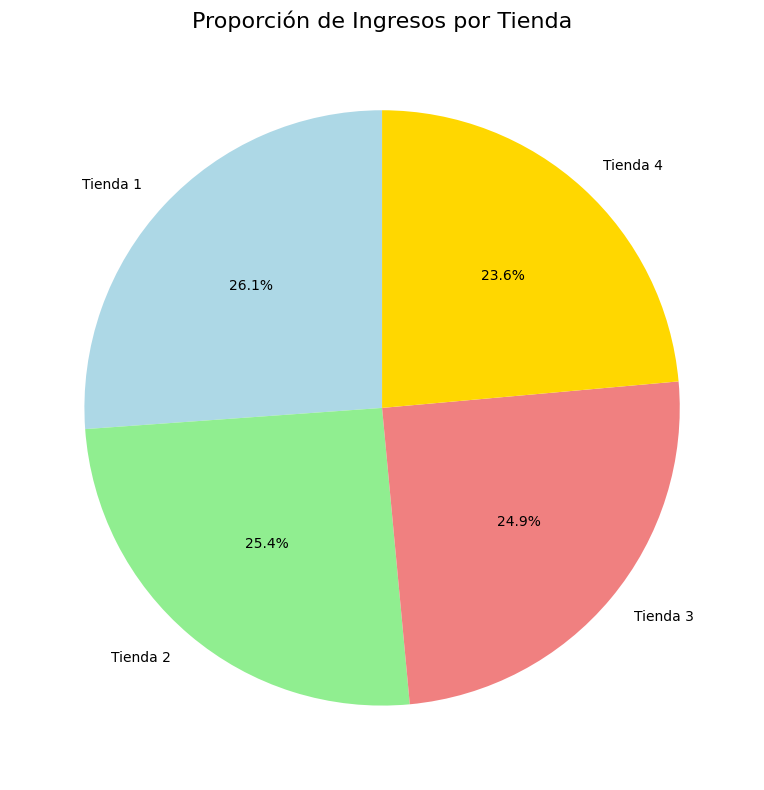

In [52]:
# Calcular los ingresos totales para cada tienda
ingresos_tienda1 = tienda['Total'].sum()
ingresos_tienda2 = tienda2['Total'].sum()
ingresos_tienda3 = tienda3['Total'].sum()
ingresos_tienda4 = tienda4['Total'].sum()

# Crear un DataFrame con los resultados
data = {
    'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4', 'Total'],
    'Ingresos Totales': [ingresos_tienda1, ingresos_tienda2, ingresos_tienda3, ingresos_tienda4, suma_total]
}
df_ingresos = pd.DataFrame(data)

# Crear un gráfico de pastel
plt.figure(figsize=(8, 8))
plt.pie(
    df_ingresos['Ingresos Totales'][:-1],  # Excluir la última fila ('Total')
    labels=df_ingresos['Tienda'][:-1],  # Excluir la última fila ('Total')
    autopct='%1.1f%%',  # Mostrar porcentajes
    startangle=90,
    colors=['lightblue', 'lightgreen', 'lightcoral', 'gold']
)
plt.title('Proporción de Ingresos por Tienda', fontsize=16)
plt.tight_layout()
plt.show()

### Productos vendidos por tienda y por categoría

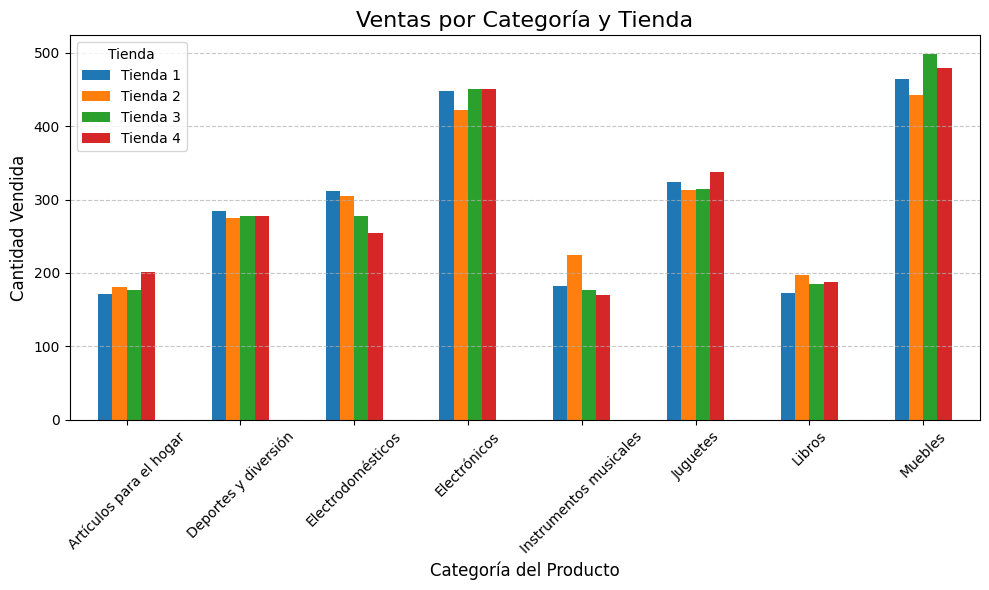

In [53]:

# Crear una tabla pivot para organizar los datos
tabla_pivot = ventas_por_tienda_categoria.pivot(
    index='Categoría del Producto',  # Eje X: Categorías
    columns='Tienda',               # Separar por tienda
    values='Cantidad Vendida'       # Valores: Cantidad vendida
).fillna(0)  # Rellenar valores faltantes con 0

# Crear el gráfico de barras
tabla_pivot.plot(kind='bar', figsize=(10, 6), rot=45)

# Personalizar el gráfico
plt.title('Ventas por Categoría y Tienda', fontsize=16)
plt.xlabel('Categoría del Producto', fontsize=12)
plt.ylabel('Cantidad Vendida', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Tienda')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

###  Calificación promedio de la tienda

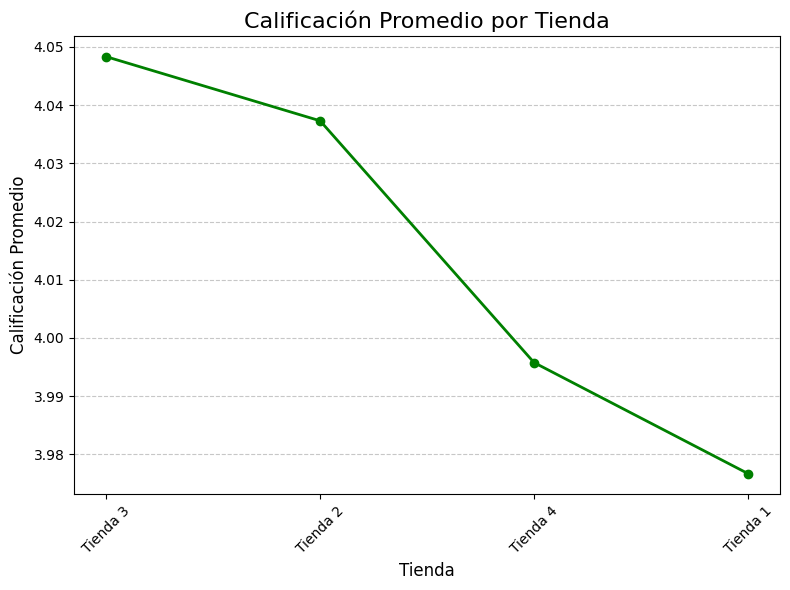

In [54]:
# Crear un gráfico de líneas
plt.figure(figsize=(8, 6))
plt.plot(
    promedio_por_tienda_ordenado['Tienda'],
    promedio_por_tienda_ordenado['Calificación Promedio'],
    marker='o',
    color='green',
    linestyle='-',
    linewidth=2
)

# Personalizar el gráfico
plt.title('Calificación Promedio por Tienda', fontsize=16)
plt.xlabel('Tienda', fontsize=12)
plt.ylabel('Calificación Promedio', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

### Productos más y menos vendidos

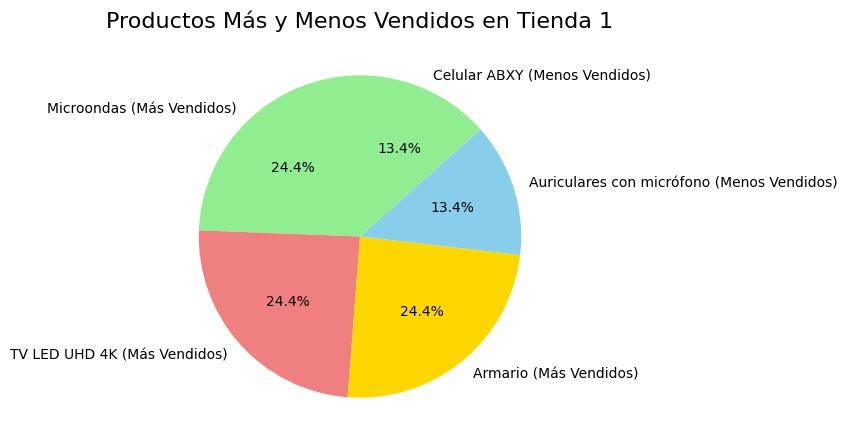

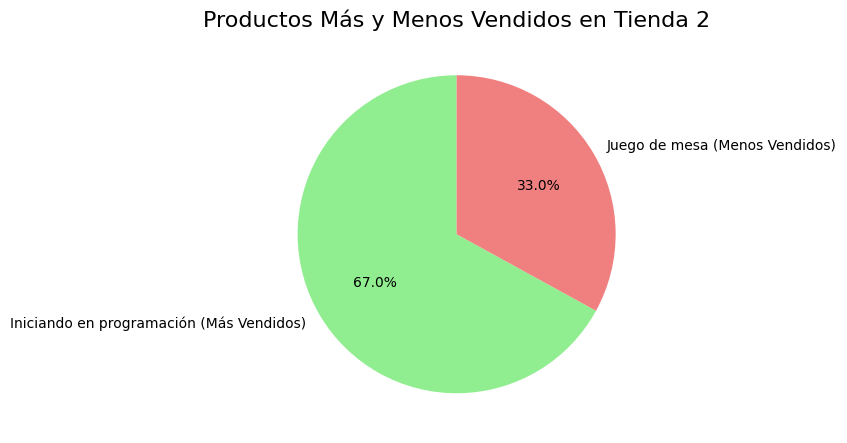

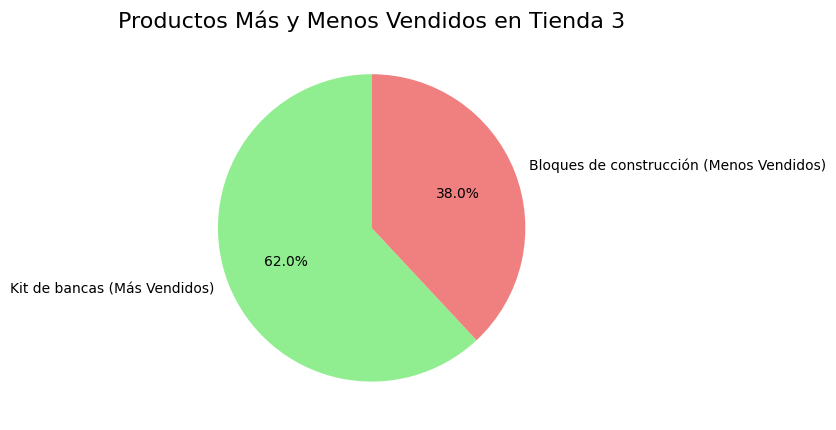

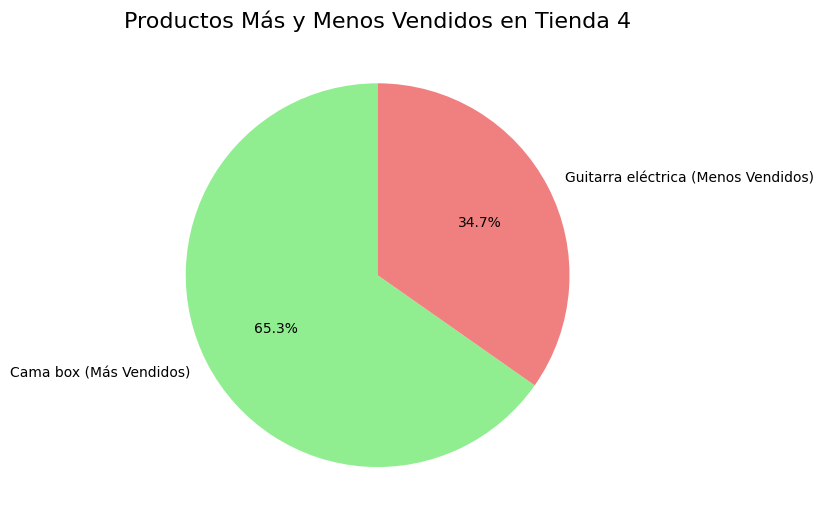

In [76]:
# Función para graficar un gráfico circular
def graficar_circular(mas_vendidos, menos_vendidos, tienda_nombre):
    # Combinar los datos de más y menos vendidos
    datos_grafico = pd.concat([
        mas_vendidos.assign(Tipo='Más Vendidos'),
        menos_vendidos.assign(Tipo='Menos Vendidos')
    ])
    
    # Extraer los nombres de los productos y las cantidades de ventas
    etiquetas = datos_grafico['Producto'] + ' (' + datos_grafico['Tipo'] + ')'
    valores = datos_grafico['Total Ventas']
    
    # Crear el gráfico circular
    plt.figure(figsize=(8, 8))
    plt.pie(
        valores,
        labels=etiquetas,
        autopct='%1.1f%%',  # Mostrar porcentajes
        startangle=90,      # Ángulo inicial
        colors=['lightgreen', 'lightcoral', 'gold', 'skyblue']  # Colores personalizados
    )
    
    # Personalizar el gráfico
    plt.title(f'Productos Más y Menos Vendidos en {tienda_nombre}', fontsize=16)
    
    # Mostrar el gráfico
    plt.tight_layout()
    plt.show()

# Graficar para cada tienda
graficar_circular(mas_vendidos_tienda1, menos_vendidos_tienda1, 'Tienda 1')
graficar_circular(mas_vendidos_tienda2, menos_vendidos_tienda2, 'Tienda 2')
graficar_circular(mas_vendidos_tienda3, menos_vendidos_tienda3, 'Tienda 3')
graficar_circular(mas_vendidos_tienda4, menos_vendidos_tienda4, 'Tienda 4')

### Costo de envío promedio por cada tienda

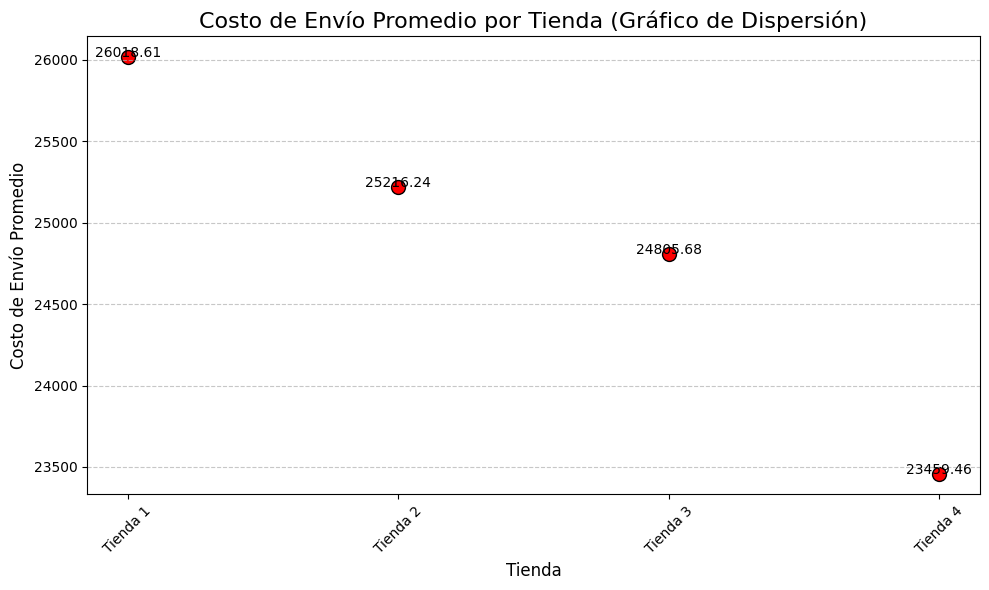

In [62]:
# Crear el gráfico de barras verticales
plt.figure(figsize=(10, 6))
plt.scatter(
    costo_envio_promedio_por_tienda['Tienda'],
    costo_envio_promedio_por_tienda['Costo de Envío Promedio'],
    color='red',
    s=100,
    edgecolor='black'
)

# Añadir etiquetas a los puntos
for i, row in costo_envio_promedio_por_tienda.iterrows():
    plt.text(
        row['Tienda'],
        row['Costo de Envío Promedio'] + 0.2,
        f"{row['Costo de Envío Promedio']:.2f}",
        ha='center',
        fontsize=10
    )

# Personalizar el gráfico
plt.title('Costo de Envío Promedio por Tienda (Gráfico de Dispersión)', fontsize=16)
plt.xlabel('Tienda', fontsize=12)
plt.ylabel('Costo de Envío Promedio', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

# Informe del análisis

#### En este trabajo analizamos los datos proveídos por el Señor Juan de las cuatro tiendas Allure Store de ventas que le pertenecen de modo a poder tomar decisiones de acuerdo al ciertas características de las mismas, como el nivel de ventas de cada una, cuáles son los artículos vendidos según su categoría, los productos más y menos vendidos en cada tienda, promedio de los costos de envío, etc.

#### Como resúmen del análisis de los datos podemos mencionar que la tienda con más ventas es la Tienda 1 con 1.150.880.400 $, el fuerte de esta tienda es la venta de electrodomésticos y posee el mayor costo de envío de todas las tiendas, sin embargo ésta no es la tienda con mejor calificación de parte de los clientes, la tienda mejor calificada es la Tienda Nro 3 que posee la mayor cantidad de ventas de muebles.

#### La tienda con menos ventas es la Nº 4 con sólo: 1.038.375.700 $  pero tiene la mayor cantidad de ventas de juguetes, se ubica en la tercera posición en la venta de muebles y está calificada en el penúltimo puesto según el promedio de calificación de los clientes, aunque no podemos dejar de mencionar que posee el menor costo promedio de envíos.

#### Cada tienda posee una categoría que es "su fuerte" sin dejar de lado la venta de muebles que es la categoría con más ventas,  La tienda Nº 1 su fuerte son los electrodomésticos, la Tienda Nº 2 son Deportes y diversión, la Tienda Nº 3 Electrónicos y la Nº 4 los juguetes y artículos para el hogar.


### Luego de un análisis exhaustivo de todas las caracterísitcas de las tiendas, la tienda a vender sería la Tienda Nº 4 debido a las siguientes razones:
### *Menores ingresos totales.
### *Penúltima en calificación de clientes.
### *No lidera en categorías clave como muebles o productos populares.
### *Aunque tiene el menor costo de envío, esto no compensa su bajo rendimiento en otros aspectos.

### Posterior a la venta de esta tienda podríamos redistribuir recursos :usar los recursos obtenidos con la venta de la Tienda 4 para mejorar las otras tiendas, especialmente en áreas como satisfacción del cliente (Tienda 1) o expansión de categorías (Tienda 2),Optimizar costos de envío :aprovechar el modelo de bajo costo de envío de la Tienda 4 para implementarlo en las otras tiendas si es viable.











# Extras

# 1. 

In [77]:
# Crear un DataFrame con las coordenadas y los ingresos totales
datos_mapa = pd.DataFrame({
    'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
    'Latitud': [tienda['lat'].iloc[0], tienda2['lat'].iloc[0], tienda3['lat'].iloc[0], tienda4['lat'].iloc[0]],
    'Longitud': [tienda['lon'].iloc[0], tienda2['lon'].iloc[0], tienda3['lon'].iloc[0], tienda4['lon'].iloc[0]],
    'Total Ventas': [
        tienda['Total'].sum(),
        tienda2['Total'].sum(),
        tienda3['Total'].sum(),
        tienda4['Total'].sum()
    ]
})

print(datos_mapa)

     Tienda   Latitud  Longitud  Total Ventas
0  Tienda 1   4.60971 -74.08175  1.150880e+09
1  Tienda 2   6.25184 -75.56359  1.116344e+09
2  Tienda 3  11.24079 -74.19904  1.098020e+09
3  Tienda 4   4.60971 -74.08175  1.038376e+09


In [94]:

import folium
import webbrowser
import os

# Calcular el centro del mapa
centro_mapa = [datos_mapa['Latitud'].mean(), datos_mapa['Longitud'].mean()]

#Como la tienda 1 y la tienda 4 están muy cerca, se ajustan las coordenadas para que no se superpongan
datos_mapa.loc[3, 'Latitud'] += 0.002  # Mover Tienda 4 ligeramente hacia el norte

# Crear el mapa
mapa = folium.Map(location=centro_mapa, zoom_start=7)  # Zoom ajustado para mostrar todas las tiendas

# Añadir marcadores para cada tienda
for _, fila in datos_mapa.iterrows():
    folium.CircleMarker(
        location=[fila['Latitud'], fila['Longitud']],
        radius=fila['Total Ventas'] / 1e8,  # Escalar el radio según las ventas
        color='red',
        fill=True,
        fill_color='red',
        fill_opacity=0.6,
        popup=f"{fila['Tienda']} - Ventas: ${fila['Total Ventas']:,.2f}"
    ).add_to(mapa)

# Guardar el mapa como un archivo HTML
archivo_html = "mapa_ventas.html"
mapa.save(archivo_html)

# Abrir automáticamente el archivo HTML en el navegador
ruta_absoluta = os.path.abspath(archivo_html)
webbrowser.open(f"file://{ruta_absoluta}")

print("Mapa guardado y abierto automáticamente.")

Mapa guardado y abierto automáticamente.
